# Turning Up the Heat: How Temperature Shapes LLM Personality

**Author**: Palatine Rigaut  
**Date**: January 2026

## 1. Libraries import

In [199]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import networkx as nx

## 2. Global constants (names + style)

In [200]:
TRAIT_ABBR_TO_FULL = {
    "O": "Openness",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism",
}
TRAIT_ORDER_ABBR = ["O", "C", "E", "A", "N"]
TRAIT_ORDER_FULL = [TRAIT_ABBR_TO_FULL[t] for t in TRAIT_ORDER_ABBR]

ACCENT = "#ff6f61"

mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def panel_label(ax, letter):
    ax.text(
        0.01, 0.98, f"({letter})",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=16, fontweight="bold"
    )

letters = "abcde"

## 3. Directed Acyclic Graph

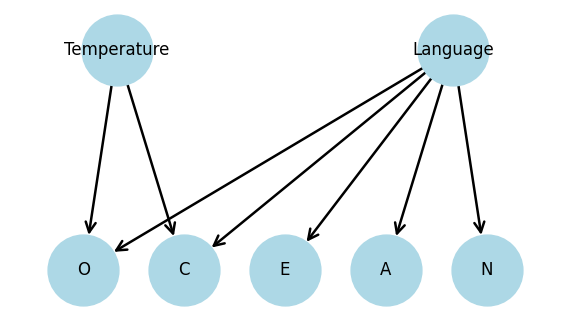

In [201]:
G = nx.DiGraph()

nodes = ["Temperature", "Language", "O", "C", "E", "A", "N"]
G.add_nodes_from(nodes)

edges = [
    ("Temperature", "O"),
    ("Temperature", "C"),
    ("Language", "O"),
    ("Language", "C"),
    ("Language", "E"),
    ("Language", "A"),
    ("Language", "N"),
]
G.add_edges_from(edges)

pos = {
    "Temperature": (-1.0,  1.0),
    "Language":    ( 1.0,  1.0),
    "O":           (-1.2, -0.2),
    "C":           (-0.6, -0.2),
    "E":           ( 0.0, -0.2),
    "A":           ( 0.6, -0.2),
    "N":           ( 1.2, -0.2),
}

plt.figure(figsize=(5.5, 3))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2600,
    node_color="lightblue",
    arrows=True,
    arrowstyle="->",
    arrowsize=18,
    width=1.8
)
plt.margins(0.12)
plt.show()

## 3. Data import

### 3.a. IPIP-50 responses (LLM)

In [202]:
df_ipip = pd.read_csv('ipip50_responses_wide.csv')
display(df_ipip)

,timestamp_utc,model,temperature,language,language_iso,item_1,item_2,item_3,item_4,item_5,...,item_41,item_42,item_43,item_44,item_45,item_46,item_47,item_48,item_49,item_50
0,2026-01-24T18:58:28.345782+00:00,gpt-4.1-mini,0.4,Maithili,mai,4,2,5,3,5,...,4,5,4,3,4,2,3,5,3,4
1,2026-01-24T18:58:31.993674+00:00,gpt-4.1-mini,0.6,Italian,ita,2,2,5,4,2,...,5,5,5,4,5,5,5,5,4,5
2,2026-01-24T18:58:44.151763+00:00,gpt-4.1-mini,0.4,Bengali,ben,5,2,5,3,5,...,4,4,5,3,4,4,4,5,3,3
3,2026-01-24T18:58:50.481140+00:00,gpt-4.1-mini,0.4,Swahili,swa,5,2,3,4,5,...,4,5,5,4,4,4,5,5,4,5
4,2026-01-24T18:58:55.552112+00:00,gpt-4.1-mini,0.4,Sudanese Arabic,apd,5,2,5,4,5,...,4,5,5,4,5,3,5,5,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,2026-01-24T22:43:30.309676+00:00,gpt-4.1-mini,0.4,Xiang Chinese,hsn,5,2,5,4,4,...,4,5,5,4,5,2,5,5,4,5
3069,2026-01-24T22:43:34.733518+00:00,gpt-4.1-mini,0.6,Yue Chinese (Cantonese),yue,3,1,5,4,5,...,4,5,4,4,4,3,5,5,2,5
3070,2026-01-24T22:43:43.030091+00:00,gpt-4.1-mini,0.4,Swahili,swa,1,4,4,5,5,...,3,5,3,4,1,3,2,5,2,5
3071,2026-01-24T22:43:47.024842+00:00,gpt-4.1-mini,1.0,Indonesian,ind,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


### 3.b. IPIP-50 scoring key

In [203]:
df_key  = pd.read_csv('ipip50_items_key.csv')
display(df_key)

,item_number,item_text_en,trait,polarity
0,1,Am the life of the party.,E,1
1,2,Feel little concern for others.,A,-1
2,3,Am always prepared.,C,1
3,4,Get stressed out easily.,N,1
4,5,Have a rich vocabulary.,O,1
5,6,Don't talk a lot.,E,-1
6,7,Am interested in people.,A,1
7,8,Leave my belongings around.,C,-1
8,9,Am relaxed most of the time.,N,-1
9,10,Have difficulty understanding abstract ideas.,O,-1


## 4. Data manipulation

### 4.a. IPIP-50 scoring key (items → trait, polarity)

In [204]:
df_key["trait"] = df_key["trait"].map(TRAIT_ABBR_TO_FULL)
display(df_key)

,item_number,item_text_en,trait,polarity
0,1,Am the life of the party.,Extraversion,1
1,2,Feel little concern for others.,Agreeableness,-1
2,3,Am always prepared.,Conscientiousness,1
3,4,Get stressed out easily.,Neuroticism,1
4,5,Have a rich vocabulary.,Openness,1
5,6,Don't talk a lot.,Extraversion,-1
6,7,Am interested in people.,Agreeableness,1
7,8,Leave my belongings around.,Conscientiousness,-1
8,9,Am relaxed most of the time.,Neuroticism,-1
9,10,Have difficulty understanding abstract ideas.,Openness,-1


### 4.b. IPIP-50 domain scores (O/C/E/A/N)

In [205]:
df = df[df_ipip.columns[2:4]].copy()

for t in TRAIT_ORDER_FULL:
    df[f"{t}"] = 0.0

for i_item in range(1, 51):
    trait = df_key.loc[i_item - 1, "trait"]
    polarity   = df_key.loc[i_item - 1, "polarity"]
    df[f"{trait}"] += df_ipip[f"item_{i_item}"] * polarity

display(df)

,temperature,language,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
0,0.4,Maithili,26.0,20.0,14.0,19.0,17.0
1,0.6,Italian,26.0,26.0,16.0,22.0,23.0
2,0.4,Bengali,19.0,24.0,14.0,17.0,16.0
3,0.4,Swahili,21.0,19.0,13.0,18.0,22.0
4,0.4,Sudanese Arabic,24.0,23.0,12.0,15.0,27.0
...,...,...,...,...,...,...,...
3068,0.4,Xiang Chinese,24.0,26.0,13.0,22.0,25.0
3069,0.6,Yue Chinese (Cantonese),28.0,19.0,12.0,23.0,22.0
3070,0.4,Swahili,27.0,21.0,13.0,15.0,11.0
3071,1.0,Indonesian,12.0,12.0,6.0,6.0,18.0


## 5. Data description

/var/folders/4h/l2qwrhwd5rn1fq7txjbb0mhw0000gn/T/ipykernel_47686/1033809566.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[2].boxplot(


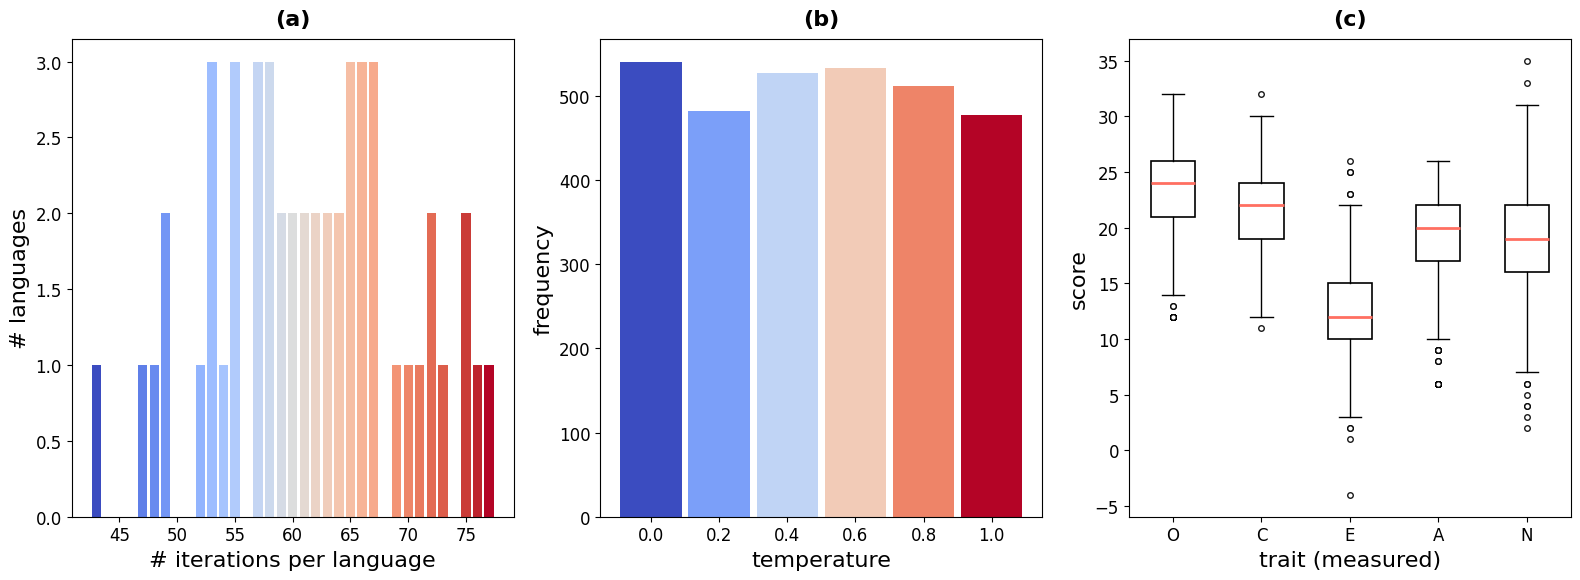

In [210]:
# --- columns ---
trait_cols = TRAIT_ORDER_FULL

# --- figure ---
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
cmap = plt.cm.coolwarm

# ------------------------------------------------------------------------- #
# 5.a. Language balance: histogram of iteration-counts per language
# ------------------------------------------------------------------------- #
lang_per_language = df["language"].value_counts()
count_hist = lang_per_language.value_counts().sort_index()

x_lang = count_hist.index.to_numpy()
y_lang = count_hist.values

lang_t = (x_lang - x_lang.min()) / (x_lang.max() - x_lang.min() + 1e-9)
ax[0].bar(x_lang, y_lang, color=cmap(lang_t), edgecolor="none")
ax[0].set_xlabel("# iterations per language")
ax[0].set_ylabel("# languages")
ax[0].set_title("(a)", fontsize=16, fontweight="bold", pad=10)

# ------------------------------------------------------------------------- #
# 5.b. Temperature distribution (discrete, equally spaced bars)
# ------------------------------------------------------------------------- #
temp_vals = pd.to_numeric(df["temperature"], errors="coerce").dropna()
temp_levels = np.sort(temp_vals.unique())
temp_step = np.min(np.diff(temp_levels)) if len(temp_levels) > 1 else 0.2

temp_counts = temp_vals.value_counts().reindex(temp_levels, fill_value=0).to_numpy()
temp_t = (temp_levels - temp_levels.min()) / (temp_levels.max() - temp_levels.min() + 1e-9)

ax[1].bar(temp_levels, temp_counts, width=0.9 * temp_step, color=cmap(temp_t), edgecolor="none")
ax[1].set_xticks(temp_levels)
ax[1].set_xlabel("temperature")
ax[1].set_ylabel("frequency")
ax[1].set_title("(b)", fontsize=16, fontweight="bold", pad=10)

# ------------------------------------------------------------------------- #
# 5.c. OCEAN measured: boxplots
# ------------------------------------------------------------------------- #
box_data = [df[c].dropna().to_numpy() for c in trait_cols]

ax[2].boxplot(
    box_data,
    labels=TRAIT_ORDER_ABBR,
    patch_artist=True,
    boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.2),
    medianprops=dict(color=ACCENT, linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markersize=4, markerfacecolor="white",
                    markeredgecolor="black", alpha=0.9)
)
ax[2].set_xlabel("trait (measured)")
ax[2].set_ylabel("score")
ax[2].set_title("(c)", fontsize=16, fontweight="bold", pad=10)

# --- panel display ---
plt.tight_layout()
plt.show()

## 6. Data modelling

We run one multivariate OLS regression per trait:

$
Y_{i}^{(T)} = \beta_0^{(T)} + \beta_1^{(T)}\,\text{Temperature}_i + \sum_{\ell}\gamma_{\ell}^{(T)}\,\mathbb{1}(\text{Language}_i=\ell) + \varepsilon_i^{(T)}
$

where $Y_i^{(T)}$ denotes the score of trait $T \in \{O,C,E,A,N\}$
The coefficient $\beta_1^{(T)}$ captures the effect of generation temperature, while language effects are included as categorical controls.

### 6.a. Regression model specification

In [ ]:
# --------- helpers ---------
def _stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def _fmt_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

def _fmt_ci(lo, hi):
    return f"[{lo:.3f}; {hi:.3f}]"

# --------- main ---------
def regression_table_per_trait(
    df=df,
    traits=TRAIT_ABBR_TO_FULL,
    y_col_from_label=lambda label: label,
    x_col="temperature",
    cat_col="language",
    show_as="display",
    dropna=True
):

    if isinstance(traits, dict):
        items = list(traits.items())
        if y_col_from_label is None:
            y_items = [(k, v) for k, v in items]
        else:
            y_items = [(y_col_from_label(v), v) for _, v in items]
    else:
        if y_col_from_label is None:
            y_items = [(t, t) for t in traits]
        else:
            y_items = [(y_col_from_label(t), t) for t in traits]

    results = {}

    for y_col, label in y_items:

        # build modelling df
        cols_needed = [y_col, x_col, cat_col]
        df_model = df[cols_needed].copy()
        if dropna:
            df_model = df_model.dropna()

        m0 = smf.ols(formula=f"{y_col} ~ {x_col}", data=df_model).fit()
        m1 = smf.ols(formula=f"{y_col} ~ {x_col} + C({cat_col})", data=df_model).fit()

        # Temperature row (from full model)
        coef = m1.params[x_col]
        se = m1.bse[x_col]
        tval = m1.tvalues[x_col]
        pval = m1.pvalues[x_col]
        ci_lo, ci_hi = m1.conf_int().loc[x_col].tolist()

        # Language global effect:
        # Δ adjusted R²
        delta_adj_r2 = float(m1.rsquared_adj - m0.rsquared_adj)

        # nested model comparison F-test (Model0 vs Model1)
        # H0: all language dummies = 0
        ftest = m1.compare_f_test(m0)
        f_stat, p_lang, df_diff = float(ftest[0]), float(ftest[1]), int(ftest[2])

        table = pd.DataFrame(
            [
                {
                    "Variable": "Temperature",
                    "Estimate": f"{coef:.3f}{_stars(pval)}",
                    "Std. Err.": f"{se:.3f}",
                    "t": f"{tval:.2f}",
                    "p-value": _fmt_p(pval),
                    "95% CI": _fmt_ci(ci_lo, ci_hi),
                },
                {
                    "Variable": "Language (global)",
                    "Estimate": f"Δ adj R² = {delta_adj_r2:.3f}",
                    "Std. Err.": "—",
                    "t": "—",
                    "p-value": _fmt_p(p_lang),
                    "95% CI": "—",
                },
            ]
        )

        meta = {
            "N": int(m1.nobs),
            "R² adj. (full)": float(m1.rsquared_adj),
            "R² adj. (temp only)": float(m0.rsquared_adj),
            "Δ adj R² (language)": delta_adj_r2,
            "F-test (language block)": f"F={f_stat:.2f}, df_diff={df_diff}, p={_fmt_p(p_lang)}",
        }

        results[label] = {"table": table, "meta": meta, "m0": m0, "m1": m1}

        # output
        if show_as == "display":
            try:
                from IPython.display import display, Markdown
                display(Markdown(f"### {label}"))
                display(table)
                display(pd.DataFrame([meta]))
            except Exception:
                print(f"\n=== {label} ===")
                print(table.to_string(index=False))
                print(pd.DataFrame([meta]).to_string(index=False))
        else:
            print(f"\n=== {label} ===")
            print(table.to_string(index=False))
            print(pd.DataFrame([meta]).to_string(index=False))

    return results

_ = regression_table_per_trait()

### Openness

,Variable,Estimate,Std. Err.,t,p-value,95% CI
0,Temperature,0.220,0.184,1.20,0.231,[-0.141; 0.581]
1,Language (global),Δ adj R² = 0.136,—,—,<0.001,—


,N,R² adj. (full),R² adj. (temp only),Δ adj R² (language),F-test (language block)
0,3073,0.135725,0.000157,0.135568,"F=10.83, df_diff=49, p=<0.001"


### Conscientiousness

,Variable,Estimate,Std. Err.,t,p-value,95% CI
0,Temperature,0.044,0.168,0.26,0.792,[-0.285; 0.373]
1,Language (global),Δ adj R² = 0.091,—,—,<0.001,—


...

,Variable,Estimate,Std. Err.,t,p-value,95% CI
0,Temperature,-0.022,0.206,-0.11,0.915,[-0.427; 0.383]
1,Language (global),Δ adj R² = 0.132,—,—,<0.001,—


,N,R² adj. (full),R² adj. (temp only),Δ adj R² (language),F-test (language block)
0,3073,0.131718,-0.000274,0.131991,"F=10.53, df_diff=49, p=<0.001"


### Neuroticism

,Variable,Estimate,Std. Err.,t,p-value,95% CI
0,Temperature,0.432**,0.210,2.06,0.040,[0.020; 0.844]
1,Language (global),Δ adj R² = 0.201,—,—,<0.001,—


,N,R² adj. (full),R² adj. (temp only),Δ adj R² (language),F-test (language block)
0,3073,0.201228,0.000411,0.200817,"F=16.76, df_diff=49, p=<0.001"


### 6.b. Forest plots (per trait)

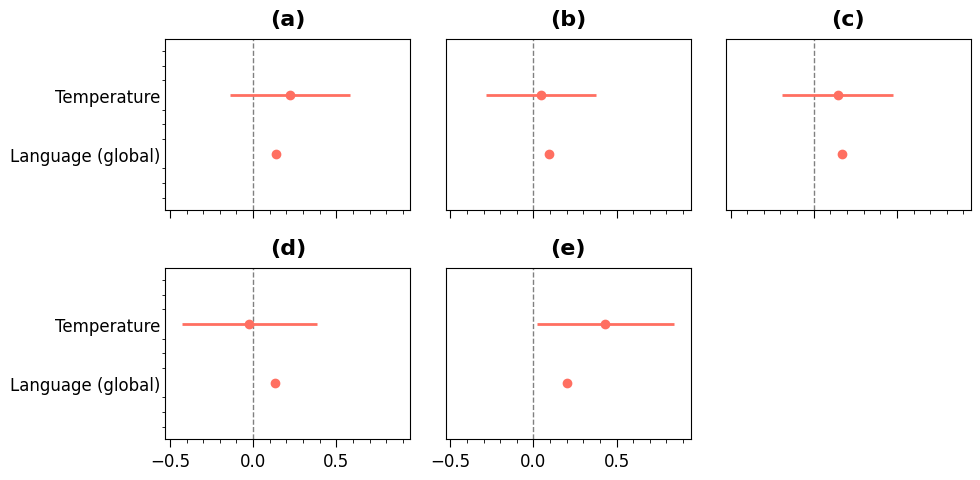

In [ ]:
def forest_panel_2x3(
    df,
    traits_order_abbr=TRAIT_ORDER_ABBR,
    trait_abbr_to_full=TRAIT_ABBR_TO_FULL,
    y_col_from_abbr=lambda abbr: TRAIT_ABBR_TO_FULL[abbr],
    x_col="temperature",
    cat_col="language",
    accent=ACCENT,
    figsize=(10, 5),
):
    n = len(traits_order_abbr)

    # Y placement
    y_temp = 0.62
    y_lang = 0.38
    y_ticks = [y_temp, y_lang]
    y_labels = ["Temperature", "Language (global)"]

    fitted = {}
    xs, cis = [], []

    # ---- 1) Fit models ----
    for abbr in traits_order_abbr:
        y = y_col_from_abbr(abbr)
        dfm = df[[y, x_col, cat_col]].dropna()

        m1 = smf.ols(f"{y} ~ {x_col} + C({cat_col})", data=dfm).fit()
        b = float(m1.params[x_col])
        lo, hi = map(float, m1.conf_int().loc[x_col])

        m0 = smf.ols(f"{y} ~ {x_col}", data=dfm).fit()
        delta_adj_r2 = float(m1.rsquared_adj - m0.rsquared_adj)

        fitted[abbr] = {"temp": (b, lo, hi), "lang": delta_adj_r2}
        xs += [b, delta_adj_r2]
        cis += [lo, hi]

    xmin, xmax = min(xs + cis), max(xs + cis)
    pad = 0.08 * (xmax - xmin + 1e-9)
    xmin, xmax = xmin - pad, xmax + pad

    # ---- 2) Plot ----
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True)
    axes = axes.ravel()

    for i, abbr in enumerate(traits_order_abbr):
        ax = axes[i]

        # title (a)-(e)
        ax.set_title(f"({letters[i]})", fontsize=16, pad=10, fontweight="bold")

        b, lo, hi = fitted[abbr]["temp"]
        delta_adj_r2 = fitted[abbr]["lang"]

        # Temperature (CI)
        ax.errorbar(
            b, y_temp,
            xerr=[[b - lo], [hi - b]],
            fmt="o",
            color=accent, ecolor=accent,
            capsize=0, linewidth=2, markersize=6, zorder=3
        )

        # Language (global)
        ax.plot(delta_adj_r2, y_lang, "o", color=accent, markersize=6, zorder=3)

        ax.axvline(0, linestyle="--", color="gray", linewidth=1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0.15, 0.85)

        ax.minorticks_on()
        ax.tick_params(axis="x", which="major", length=6)
        ax.tick_params(axis="x", which="minor", length=3)

        # Y labels only for first subplot of each row
        if i in (0, 3):
            ax.set_yticks(y_ticks)
            ax.set_yticklabels(y_labels)
        else:
            ax.set_yticks([])
            ax.set_yticklabels([])

        ax.tick_params(axis="y", length=0)

    # hide last empty panel
    axes[5].axis("off")

    plt.tight_layout()
    plt.show()
    return fitted

fitted = forest_panel_2x3(df)